## Extra Credit (Part1) -- Video detection

In [ ]:
# you will be prompted with a window asking to grant permissions
# from google.colab import drive
# drive.mount("/content/drive")

In [ ]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
# import os
# datadir = "/content/assignment4"
# if not os.path.exists(datadir):
#   !ln -s "/content/drive/MyDrive/MP4/" $datadir # TODO: Fill your Assignment 4 path
# os.chdir(datadir)
# !pwd

In [1]:
import os
import random

import cv2
import numpy as np

import torch
from torch.utils.data import DataLoader

from src.resnet_yolo import resnet50
import yolo_loss
from src.dataset import VocDetectorDataset
from src.eval_voc import evaluate
from src.predict import predict_image
from src.config import VOC_CLASSES, COLORS
from kaggle_submission import output_submission_csv

import matplotlib.pyplot as plt
import collections

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Initialization

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Transforming the video into frames

In [3]:
video_path = 'video/UIUC_Quad_day.mp4'
frames_output_dir = 'video/frames'

# Open the video file
cap = cv2.VideoCapture(video_path)

# Frame counter
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_filename = os.path.join(frames_output_dir, f"frame_{frame_idx:05d}.jpg")
    cv2.imwrite(frame_filename, frame)
    
    frame_idx += 1

cap.release()
print(f"A total of {frame_idx} frames were extracted and saved in {frames_output_dir}/")

A total of 2721 frames were extracted and saved in video/frames/


## Initializing the network

In [4]:
load_network_path = "checkpoints/best_detector.pth"
pretrained = True

# use to load a previously trained network
if load_network_path is not None:
    print('Loading saved network from {}'.format(load_network_path))
    net = resnet50().to(device)
    net.load_state_dict(torch.load(load_network_path))
else:
    print('Load pre-trained model')
    net = resnet50(pretrained=pretrained).to(device)

Loading saved network from checkpoints/best_detector.pth


In [5]:
# Print the model
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Test on one frame

Predicting...


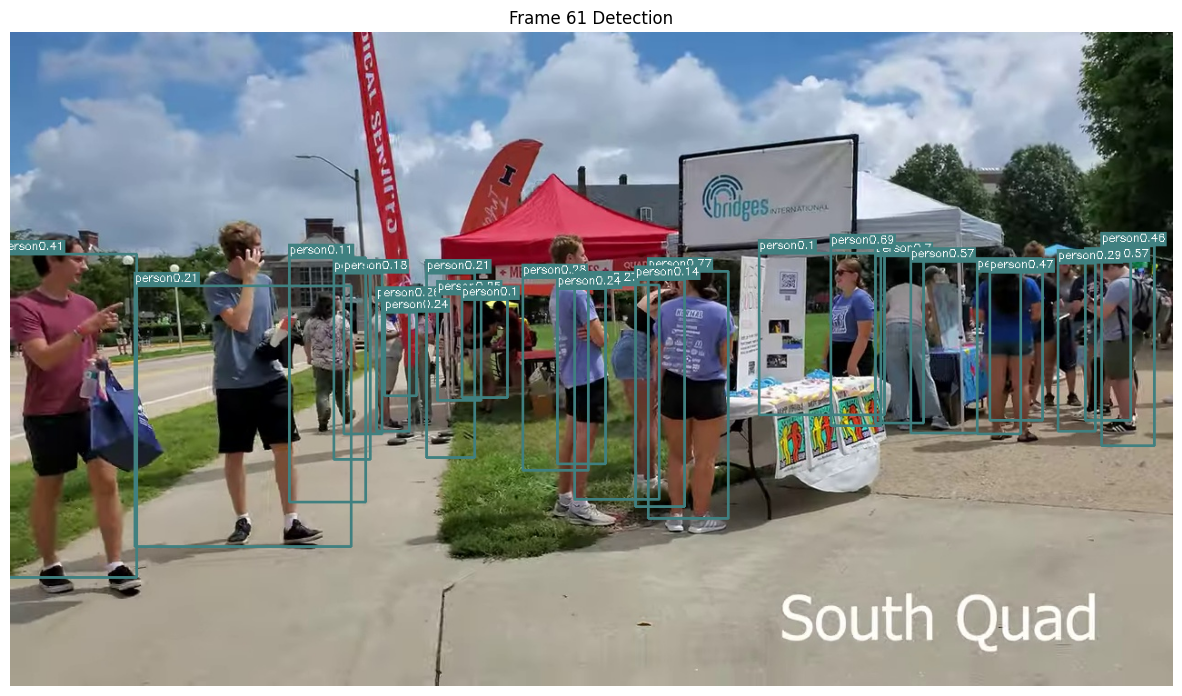

In [6]:
frames_path = "video/frames/"

# Set the model to evaluation mode
net.eval()

# Choose a frame to test
frame_idx = 61
frame_filename = f"frame_{frame_idx:05d}.jpg"
frame_filepath = os.path.join(frames_path, frame_filename)

# Load the frame and convert to RGB
image = cv2.imread(frame_filepath)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run detection model on the frame
print("Predicting...")
result = predict_image(net, frame_filename, root_img_directory=frames_path)
for left_up, right_bottom, class_name, _, prob in result:
    color = COLORS[VOC_CLASSES.index(class_name)]
    cv2.rectangle(image, left_up, right_bottom, color, 2)
    label = class_name + str(round(prob, 2))
    text_size, baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
    p1 = (left_up[0], left_up[1] - text_size[1])
    cv2.rectangle(image, (p1[0] - 2 // 2, p1[1] - 2 - baseline), (p1[0] + text_size[0], p1[1] + text_size[1]),
                  color, -1)
    cv2.putText(image, label, (p1[0], p1[1] + baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, 8)

plt.figure(figsize = (15,15))
plt.axis('off')
plt.title(f"Frame {frame_idx} Detection")
plt.imshow(image)
plt.show()

## Object Detection on all the frames

In [7]:
frames_path = "video/frames/"
detections_path = "video/detections/"

# Set the model to evaluation mode
net.eval()

# Get all the frames in the frames folder
frame_files = sorted(f for f in os.listdir(frames_path) if f.endswith(".jpg"))

# Draw the detections on all the frames
for frame_filename in frame_files:
    frame_idx = int(frame_filename.split("_")[1].split(".")[0])
    frame_filepath = os.path.join(frames_path, frame_filename)

    # Load the frame and convert to RGB
    image = cv2.imread(frame_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run detection model on the frame
    result = predict_image(net, frame_filename, root_img_directory=frames_path)
    for left_up, right_bottom, class_name, _, prob in result:
        color = COLORS[VOC_CLASSES.index(class_name)]
        cv2.rectangle(image, left_up, right_bottom, color, 2)
        label = class_name + str(round(prob, 2))
        text_size, baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        p1 = (left_up[0], left_up[1] - text_size[1])
        cv2.rectangle(image, (p1[0] - 2 // 2, p1[1] - 2 - baseline), (p1[0] + text_size[0], p1[1] + text_size[1]),
                      color, -1)
        cv2.putText(image, label, (p1[0], p1[1] + baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, 8)
    
    # Save the detected frames
    frames_save_path = os.path.join(detections_path, frame_filename)
    cv2.imwrite(frames_save_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

print(f"All frames processed, results saved in `{detections_path}`.")

All frames processed, results saved in `video/detections/`.


## Transform the detected frames back to video

In [8]:
detections_path = "video/detections/"
video_output_path = "video/UIUC_Quad_day_yolo.mp4"

# Get the list of frame files
frame_files = sorted([f for f in os.listdir(detections_path) if f.endswith(".jpg")])

# Get the size of the frames in the video
first_frame = cv2.imread(os.path.join(detections_path, frame_files[0]))
h, w, _ = first_frame.shape


cap = cv2.VideoCapture("video/UIUC_Quad_day.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

# This part is under instructions of ChatGPT
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(video_output_path, fourcc, fps, (w, h))

# Write the frames to the video
for frame_filename in frame_files:
    frame = cv2.imread(os.path.join(detections_path, frame_filename))
    if frame is None:
        print(f"Warning: failed to read {frame_filename}, skipping")
        continue
    writer.write(frame)

writer.release()
print(f"Video saved to {video_output_path}")


Video saved to video/UIUC_Quad_day_yolo.mp4
